In [1]:
import geopandas as gpd
import h3
import pandas as pd

print("h3 version:", h3.__version__)
print("sab kaam kar raha hai!")

h3 version: 4.4.1
sab kaam kar raha hai!


In [2]:
# Bangalore ka rough bounding box (chaaron taraf ki seedhi seemayein)
# format: (min_longitude, min_latitude, max_longitude, max_latitude)
bangalore_bbox = (77.4601, 12.8340, 77.7840, 13.1436)

print("Bangalore bounding box set ho gaya:", bangalore_bbox)


Bangalore bounding box set ho gaya: (77.4601, 12.834, 77.784, 13.1436)


In [3]:
# Bounding box ke 4 corners se ek band shape (polygon) banate hain
# H3 ko (latitude, longitude) order mein points chahiye — bounding box tha (longitude, latitude) order mein, isliye ulta karenge

min_lon, min_lat, max_lon, max_lat = bangalore_bbox

# Chaaron corners, clockwise order mein
corners = [
    (min_lat, min_lon),  # bottom-left
    (min_lat, max_lon),  # bottom-right
    (max_lat, max_lon),  # top-right
    (max_lat, min_lon),  # top-left
]

bangalore_shape = h3.LatLngPoly(corners)

# Ab is shape ke andar resolution-8 hexagons generate karo
resolution = 8
hex_cells = h3.polygon_to_cells(bangalore_shape, resolution)

print("Total hexagons bane:", len(hex_cells))
print("Pehle 5 hexagon IDs:", list(hex_cells)[:5])

Total hexagons bane: 1614
Pehle 5 hexagon IDs: ['8861892517fffff', '8860145b47fffff', '88618922adfffff', '8861892c55fffff', '886189203bfffff']


<Axes: >

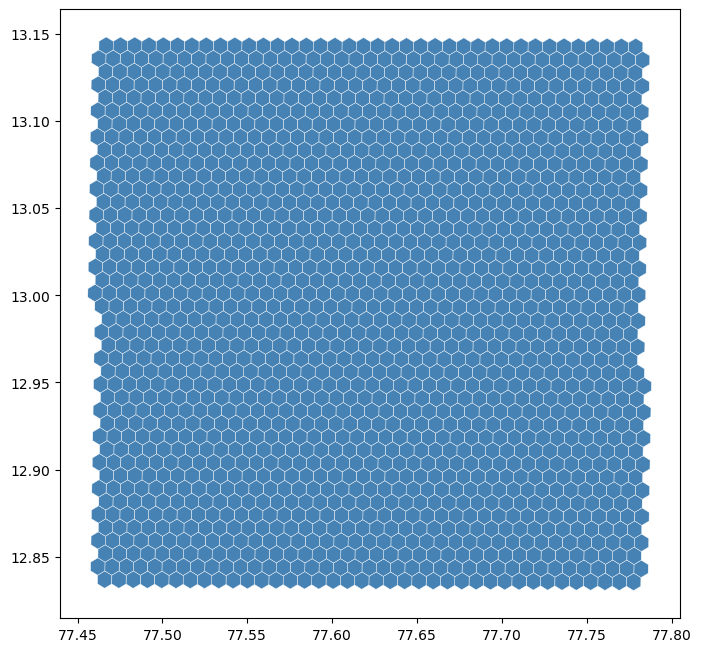

In [4]:
# Har hexagon ID ko uske boundary (corner points) mein convert karo, fir GeoDataFrame banao taaki plot kar sakein

boundaries = []
for cell in hex_cells:
    coords = h3.cell_to_boundary(cell)  # (lat, lon) pairs deta hai hexagon ke corners ke
    # shapely/geopandas ko (lon, lat) order chahiye, isliye ulta karo
    coords_lonlat = [(lon, lat) for lat, lon in coords]
    boundaries.append(coords_lonlat)

from shapely.geometry import Polygon
geometries = [Polygon(b) for b in boundaries]

gdf = gpd.GeoDataFrame({'hex_id': list(hex_cells)}, geometry=geometries, crs="EPSG:4326")

gdf.plot(figsize=(8, 8), edgecolor='white', linewidth=0.3, color='steelblue')


In [5]:
# Sirf pehle 5 rows padho — poori file load kiye bina (fast hai, kam memory leta hai)
preview_df = pd.read_csv("data/FIR_Details_Data.csv", nrows=5)

print("Columns:")
print(preview_df.columns.tolist())
print("\nPehle 5 rows:")
preview_df

Columns:
['District_Name', 'UnitName', 'FIR_YEAR', 'FIR_MONTH', 'Offence_Duration', 'FIR_Day', 'FIR Type', 'FIR_Stage', 'Complaint_Mode', 'CrimeGroup_Name', 'CrimeHead_Name', 'Latitude', 'Longitude', 'ActSection', 'IOName', 'KGID', 'Internal_IO', 'Place of Offence', 'Distance from PS', 'Beat_Name', 'Village_Area_Name', 'Male', 'Female', 'Boy', 'Girl', 'Age 0', 'VICTIM COUNT', 'Accused Count', 'Arrested Male', 'Arrested Female', 'Arrested Count\tNo.', 'Accused_ChargeSheeted Count', 'Conviction Count', 'Unit_ID']

Pehle 5 rows:


,District_Name,UnitName,FIR_YEAR,FIR_MONTH,Offence_Duration,FIR_Day,FIR Type,FIR_Stage,Complaint_Mode,CrimeGroup_Name,...,Girl,Age 0,VICTIM COUNT,Accused Count,Arrested Male,Arrested Female,Arrested Count\tNo.,Accused_ChargeSheeted Count,Conviction Count,Unit_ID
0,Bagalkot,Amengad PS,2016,1,0,5,Non Heinous,Dis/Acq,Written,POCSO,...,1,0,0,1,1,0,1,1,0,1245
1,Bagalkot,Amengad PS,2016,1,0,12,Non Heinous,Convicted,Sue-moto by Police,KARNATAKA POLICE ACT 1963,...,0,0,0,5,5,0,5,5,2,1245
2,Bagalkot,Amengad PS,2016,1,0,12,Non Heinous,Convicted,Sue-moto by Police,KARNATAKA POLICE ACT 1963,...,0,0,0,1,1,0,1,1,0,1245
3,Bagalkot,Amengad PS,2016,1,0,15,Non Heinous,Convicted,Written,MOTOR VEHICLE ACCIDENTS NON-FATAL,...,0,1,0,1,1,0,1,1,0,1245
4,Bagalkot,Amengad PS,2016,1,0,18,Heinous,Pending Trial,Written,MOTOR VEHICLE ACCIDENTS FATAL,...,0,0,0,1,1,0,1,1,0,1245


In [6]:
import os

print("Notebook kahan se chal raha hai:", os.getcwd())
print("\nIs folder ke andar kya hai:", os.listdir())

Notebook kahan se chal raha hai: /Users/rashisingh/sentinel

Is folder ke andar kya hai: ['sentinel_rf_model.pkl', 'cache', 'Untitled.ipynb', 'feature_importance.png', '.gitignore', '02_ml_model.ipynb', '01_h3_grid_setup.ipynb', '.ipynb_checkpoints', '.git', 'data', 'untitled.py']


In [7]:
print(os.listdir("data"))

['hexagon_sri_data.csv', 'ind_pd_2020_1km.tif', 'FIR_Details_Data.csv']


In [8]:
preview_df = pd.read_csv("data/FIR_Details_Data.csv", nrows=5)

print("Columns:")
print(preview_df.columns.tolist())
print("\nPehle 5 rows:")
preview_df

Columns:
['District_Name', 'UnitName', 'FIR_YEAR', 'FIR_MONTH', 'Offence_Duration', 'FIR_Day', 'FIR Type', 'FIR_Stage', 'Complaint_Mode', 'CrimeGroup_Name', 'CrimeHead_Name', 'Latitude', 'Longitude', 'ActSection', 'IOName', 'KGID', 'Internal_IO', 'Place of Offence', 'Distance from PS', 'Beat_Name', 'Village_Area_Name', 'Male', 'Female', 'Boy', 'Girl', 'Age 0', 'VICTIM COUNT', 'Accused Count', 'Arrested Male', 'Arrested Female', 'Arrested Count\tNo.', 'Accused_ChargeSheeted Count', 'Conviction Count', 'Unit_ID']

Pehle 5 rows:


,District_Name,UnitName,FIR_YEAR,FIR_MONTH,Offence_Duration,FIR_Day,FIR Type,FIR_Stage,Complaint_Mode,CrimeGroup_Name,...,Girl,Age 0,VICTIM COUNT,Accused Count,Arrested Male,Arrested Female,Arrested Count\tNo.,Accused_ChargeSheeted Count,Conviction Count,Unit_ID
0,Bagalkot,Amengad PS,2016,1,0,5,Non Heinous,Dis/Acq,Written,POCSO,...,1,0,0,1,1,0,1,1,0,1245
1,Bagalkot,Amengad PS,2016,1,0,12,Non Heinous,Convicted,Sue-moto by Police,KARNATAKA POLICE ACT 1963,...,0,0,0,5,5,0,5,5,2,1245
2,Bagalkot,Amengad PS,2016,1,0,12,Non Heinous,Convicted,Sue-moto by Police,KARNATAKA POLICE ACT 1963,...,0,0,0,1,1,0,1,1,0,1245
3,Bagalkot,Amengad PS,2016,1,0,15,Non Heinous,Convicted,Written,MOTOR VEHICLE ACCIDENTS NON-FATAL,...,0,1,0,1,1,0,1,1,0,1245
4,Bagalkot,Amengad PS,2016,1,0,18,Heinous,Pending Trial,Written,MOTOR VEHICLE ACCIDENTS FATAL,...,0,0,0,1,1,0,1,1,0,1245


In [9]:
cols_needed = ['District_Name', 'FIR_YEAR', 'FIR_MONTH', 'FIR Type', 
               'CrimeGroup_Name', 'Latitude', 'Longitude']
crime_df = pd.read_csv("data/FIR_Details_Data.csv", usecols=cols_needed)
print("Total records:", len(crime_df))
print("\nDistricts mein kya-kya hai (top 10):")
print(crime_df['District_Name'].value_counts().head(10))

Total records: 1674734

Districts mein kya-kya hai (top 10):
District_Name
Bengaluru City    425408
Bengaluru Dist     64004
Tumakuru           61553
Shivamogga         61338
Mandya             59701
Belagavi Dist      59569
Hassan             58256
Mysuru Dist        50599
Chitradurga        47754
Ramanagara         44232
Name: count, dtype: int64


In [10]:
cols_needed = ['District_Name', 'FIR_YEAR', 'FIR_MONTH', 'FIR Type', 
               'CrimeGroup_Name', 'Latitude', 'Longitude']

crime_df = pd.read_csv("data/FIR_Details_Data.csv", usecols=cols_needed)

print("Total records:", len(crime_df))
print("\nDistricts mein kya-kya hai (top 10):")
print(crime_df['District_Name'].value_counts().head(10))

Total records: 1674734

Districts mein kya-kya hai (top 10):
District_Name
Bengaluru City    425408
Bengaluru Dist     64004
Tumakuru           61553
Shivamogga         61338
Mandya             59701
Belagavi Dist      59569
Hassan             58256
Mysuru Dist        50599
Chitradurga        47754
Ramanagara         44232
Name: count, dtype: int64


In [11]:
# Sirf Bengaluru City ka data nikaalo
bangalore_crime = crime_df[crime_df['District_Name'] == 'Bengaluru City'].copy()

print("Bengaluru City records:", len(bangalore_crime))

# Kitni rows mein Latitude/Longitude missing hai
missing_location = bangalore_crime['Latitude'].isna().sum()
print("Missing Latitude values:", missing_location, f"({missing_location/len(bangalore_crime)*100:.1f}%)")

# Crime categories — top 15
print("\nTop 15 crime types (Bengaluru City):")
print(bangalore_crime['CrimeGroup_Name'].value_counts().head(15))

Bengaluru City records: 425408
Missing Latitude values: 278000 (65.3%)

Top 15 crime types (Bengaluru City):
CrimeGroup_Name
THEFT                                       69988
 CYBER CRIME                                64599
MISSING PERSON                              39234
PUBLIC SAFETY                               32222
MOTOR VEHICLE ACCIDENTS NON-FATAL           30107
CASES OF HURT                               23116
CHEATING                                    22716
NARCOTIC DRUGS & PSHYCOTROPIC SUBSTANCES    16247
NEGLIGENT ACT                               15141
CrPC                                        10878
KIDNAPPING AND ABDUCTION                     7924
BURGLARY - NIGHT                             7890
MOLESTATION                                  6455
Karnataka State Local Act                    6304
ROBBERY                                      6126
Name: count, dtype: int64


In [12]:
# Sirf valid latitude/longitude wali rows rakho
bangalore_crime_geo = bangalore_crime.dropna(subset=['Latitude', 'Longitude']).copy()
print("Usable records (valid location):", len(bangalore_crime_geo))

# Har crime ko uske H3 hexagon mein map karo
resolution = 8
bangalore_crime_geo['hex_id'] = bangalore_crime_geo.apply(
    lambda row: h3.latlng_to_cell(row['Latitude'], row['Longitude'], resolution),
    axis=1
)

print("\nSample rows with hex_id:")
bangalore_crime_geo[['Latitude', 'Longitude', 'hex_id', 'CrimeGroup_Name']].head(10)

Usable records (valid location): 147367

Sample rows with hex_id:


,Latitude,Longitude,hex_id,CrimeGroup_Name
136995,12.943114,77.610126,886189258dfffff,CrPC
136996,12.947056,77.600770,8861892587fffff,CRIMINAL INTIMIDATION
136997,12.945529,77.601972,8861892581fffff,CASES OF HURT
136998,12.940740,77.613258,886189258dfffff,CHEATING
136999,12.937447,77.601939,8861892581fffff,ROBBERY
137000,12.946512,77.599461,8861892587fffff,ROBBERY
137001,12.946512,77.599461,8861892587fffff,MISSING PERSON
137002,12.938869,77.609109,886189258dfffff,Karnataka State Local Act
137003,12.939590,77.601628,8861892581fffff,CrPC
137004,12.942142,77.600749,8861892581fffff,MISSING PERSON


In [13]:
# Har hexagon mein kitne crimes hue, unko count karo
crime_counts = bangalore_crime_geo.groupby('hex_id').size().reset_index(name='crime_count')

print("Kitne unique hexagons mein crimes hue:", len(crime_counts))
print("\nSabse zyada crime wale top 10 hexagons:")
print(crime_counts.sort_values('crime_count', ascending=False).head(10))

Kitne unique hexagons mein crimes hue: 5567

Sabse zyada crime wale top 10 hexagons:
               hex_id  crime_count
1966  8860145b59fffff         1393
4697  88618925b7fffff         1358
1968  8860145b5dfffff         1278
187   880151891dfffff         1023
4695  88618925b3fffff          965
5045  8861892e29fffff          916
1852  8860145a2bfffff          900
1950  8860145b35fffff          871
200   8801518957fffff          866
5526  88754c61e9fffff          800


Text(0.5, 1.0, 'Bengaluru Crime Density by H3 Hexagon')

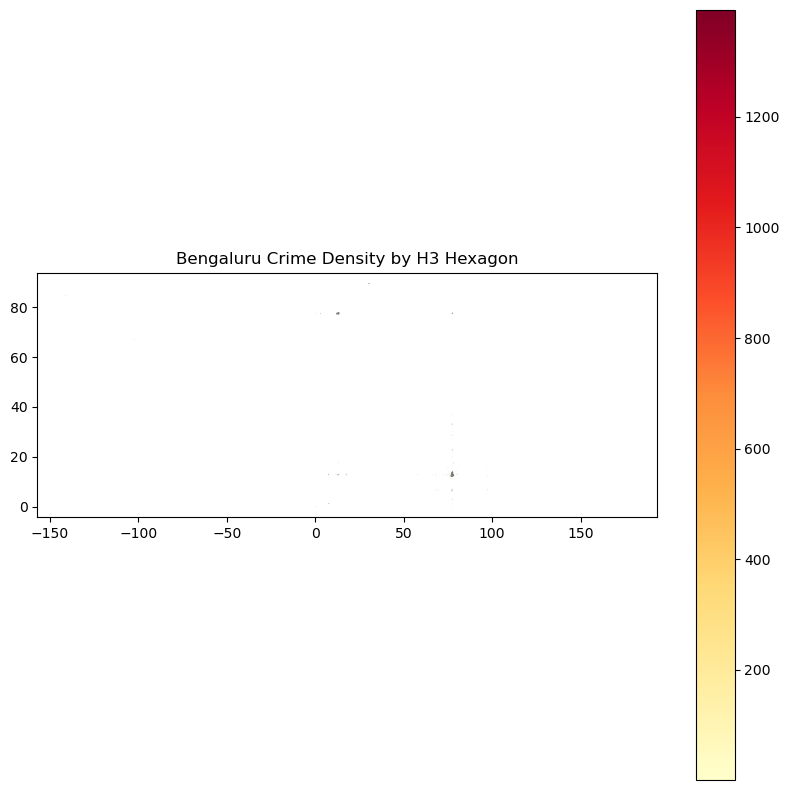

In [14]:
# Har hexagon ID ko uske shape (polygon) mein convert karo
def hex_to_polygon(hex_id):
    coords = h3.cell_to_boundary(hex_id)
    coords_lonlat = [(lon, lat) for lat, lon in coords]
    return Polygon(coords_lonlat)

crime_counts['geometry'] = crime_counts['hex_id'].apply(hex_to_polygon)

crime_gdf = gpd.GeoDataFrame(crime_counts, geometry='geometry', crs="EPSG:4326")

# Heatmap plot karo — jitna zyada crime, utna gehra rang
ax = crime_gdf.plot(
    column='crime_count',
    cmap='YlOrRd',
    figsize=(10, 10),
    edgecolor='grey',
    linewidth=0.2,
    legend=True
)
ax.set_title("Bengaluru Crime Density by H3 Hexagon")

In [15]:
print("Latitude range:", bangalore_crime_geo['Latitude'].min(), "to", bangalore_crime_geo['Latitude'].max())
print("Longitude range:", bangalore_crime_geo['Longitude'].min(), "to", bangalore_crime_geo['Longitude'].max())


Latitude range: 0.120009 to 131.42999
Longitude range: 0.0450525796353 to 777.744746


In [16]:
# Sirf Bengaluru ke reasonable geographic range wale records rakho
bangalore_crime_clean = bangalore_crime_geo[
    (bangalore_crime_geo['Latitude'] >= 12.7) & (bangalore_crime_geo['Latitude'] <= 13.2) &
    (bangalore_crime_geo['Longitude'] >= 77.3) & (bangalore_crime_geo['Longitude'] <= 77.9)
].copy()

print("Pehle records the:", len(bangalore_crime_geo))
print("Ab (clean) records hain:", len(bangalore_crime_clean))
print("Kitne records hataye gaye (bad data):", len(bangalore_crime_geo) - len(bangalore_crime_clean))

Pehle records the: 147367
Ab (clean) records hain: 118210
Kitne records hataye gaye (bad data): 29157


Text(0.5, 1.0, 'Bengaluru Crime Density by H3 Hexagon (Cleaned)')

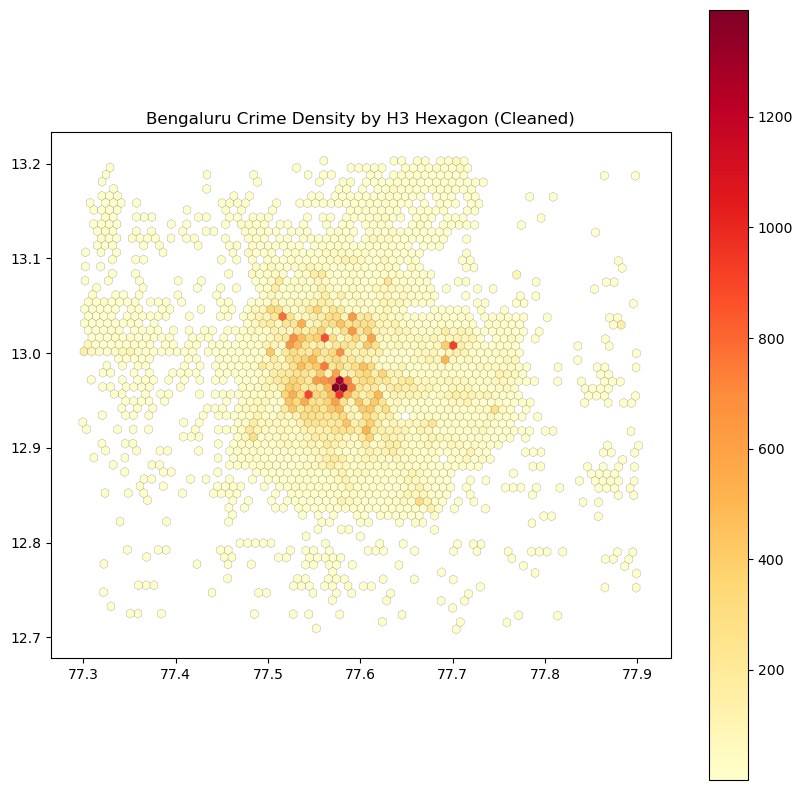

In [17]:
# Dobara count karo, is baar clean data se
crime_counts_clean = bangalore_crime_clean.groupby('hex_id').size().reset_index(name='crime_count')

crime_counts_clean['geometry'] = crime_counts_clean['hex_id'].apply(hex_to_polygon)
crime_gdf_clean = gpd.GeoDataFrame(crime_counts_clean, geometry='geometry', crs="EPSG:4326")

ax = crime_gdf_clean.plot(
    column='crime_count',
    cmap='YlOrRd',
    figsize=(10, 10),
    edgecolor='grey',
    linewidth=0.2,
    legend=True
)
ax.set_title("Bengaluru Crime Density by H3 Hexagon (Cleaned)")

In [18]:
print(bangalore_crime_clean['FIR Type'].value_counts())

FIR Type
Non Heinous    108203
Heinous         10007
Name: count, dtype: int64


In [19]:
# Women-safety-relevant crime types (jo Heinous nahi hain officially, lekin direct-relevant hain)
priority_crimes = ['MOLESTATION', 'KIDNAPPING AND ABDUCTION', 'CRIMINAL INTIMIDATION', 
                    'STALKING', 'EVE TEASING', 'CASES OF HURT']

def assign_weight(row):
    if row['FIR Type'].strip() == 'Heinous':
        return 3
    elif row['CrimeGroup_Name'].strip().upper() in priority_crimes:
        return 2
    else:
        return 1

bangalore_crime_clean['risk_weight'] = bangalore_crime_clean.apply(assign_weight, axis=1)

print(bangalore_crime_clean['risk_weight'].value_counts())

risk_weight
1    95188
2    13015
3    10007
Name: count, dtype: int64


In [20]:
# Har hexagon ka weighted risk score = us hexagon ke saare crimes ke weights ka total
hex_risk = bangalore_crime_clean.groupby('hex_id')['risk_weight'].sum().reset_index(name='raw_risk_score')

print("Total hexagons with risk score:", len(hex_risk))
print("\nTop 10 riskiest hexagons (weighted):")
print(hex_risk.sort_values('raw_risk_score', ascending=False).head(10))

Total hexagons with risk score: 2004

Top 10 riskiest hexagons (weighted):
               hex_id  raw_risk_score
730   8860145b59fffff            1654
1445  88618925b7fffff            1628
732   8860145b5dfffff            1595
1793  8861892e29fffff            1333
616   8860145a2bfffff            1241
1443  88618925b3fffff            1191
704   8860145b1dfffff             969
444   886014582dfffff             958
519   8860145913fffff             949
714   8860145b35fffff             911


In [21]:
import rasterio

print("rasterio load ho gaya")

rasterio load ho gaya


In [22]:
# GeoTIFF file kholo
pop_raster = rasterio.open("data/ind_pd_2020_1km.tif")

print("Raster ka size (width x height):", pop_raster.width, "x", pop_raster.height)
print("Raster ka coordinate system:", pop_raster.crs)
print("Raster ka data area (bounds):", pop_raster.bounds)

Raster ka size (width x height): 3508 x 3451
Raster ka coordinate system: EPSG:4326
Raster ka data area (bounds): BoundingBox(left=68.18208306817596, bottom=6.7495834993281605, right=97.41541628457595, top=35.50791671762816)


In [23]:
# H3 grid (jo humne sabse pehle banaya tha - 'gdf') mein har hexagon ka center point nikaalो
gdf['centroid'] = gdf.geometry.centroid
gdf['center_lat'] = gdf['centroid'].y
gdf['center_lon'] = gdf['centroid'].x

# Ab har center point pe raster se population value "sample" karo
coords = list(zip(gdf['center_lon'], gdf['center_lat']))
population_values = [val[0] for val in pop_raster.sample(coords)]

gdf['population_density'] = population_values

print(gdf[['hex_id', 'center_lat', 'center_lon', 'population_density']].head(10))

            hex_id  center_lat  center_lon  population_density
0  8861892517fffff   12.940921   77.636110        13300.427734
1  8860145b47fffff   12.985994   77.586311        25918.917969
2  88618922adfffff   12.910460   77.762097         1334.467407
3  8861892c55fffff   13.030638   77.662929          914.680481
4  886189203bfffff   12.947923   77.758528          437.932281
5  88618922a5fffff   12.917967   77.758008         1466.300537
6  8861892c4dfffff   13.030552   77.688231          386.660126
7  8861892eb7fffff   13.015838   77.612093        50985.109375
8  8861892033fffff   12.955430   77.754439          242.736099
9  886189229dfffff   12.880616   77.736266         1136.076782


/var/folders/rb/6sdjdvpn5plchw87422y61nh0000gn/T/ipykernel_52253/1872331114.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['centroid'] = gdf.geometry.centroid


In [24]:
# Crime risk score aur population data ko ek saath jodo (hex_id ke through)
sri_df = hex_risk.merge(gdf[['hex_id', 'population_density']], on='hex_id', how='left')

print("Merged rows:", len(sri_df))
print(sri_df.head(10))

Merged rows: 2004
            hex_id  raw_risk_score  population_density
0  8860144003fffff               1                 NaN
1  8860144005fffff               1                 NaN
2  8860144007fffff               2                 NaN
3  8860144009fffff               1                 NaN
4  886014400dfffff               2                 NaN
5  8860144011fffff               3                 NaN
6  8860144017fffff               3                 NaN
7  886014401dfffff               1                 NaN
8  8860144021fffff               3                 NaN
9  8860144023fffff               3                 NaN


In [25]:
# hex_risk ke har hex_id ka apna centroid nikaalो aur population sample karo — gdf pe depend na karo
sri_df['centroid_lonlat'] = sri_df['hex_id'].apply(lambda h: h3.cell_to_latlng(h))
sri_df['center_lat'] = sri_df['centroid_lonlat'].apply(lambda x: x[0])
sri_df['center_lon'] = sri_df['centroid_lonlat'].apply(lambda x: x[1])

coords = list(zip(sri_df['center_lon'], sri_df['center_lat']))
sri_df['population_density'] = [val[0] for val in pop_raster.sample(coords)]

sri_df = sri_df.drop(columns=['centroid_lonlat'])

print("Missing population values:", sri_df['population_density'].isna().sum())
print(sri_df.head(10))

Missing population values: 0
            hex_id  raw_risk_score  population_density  center_lat  center_lon
0  8860144003fffff               1          101.273232   12.941812   77.358424
1  8860144005fffff               1           97.508835   12.949251   77.371147
2  8860144007fffff               2          101.273232   12.949274   77.362744
3  8860144009fffff               1          115.839203   12.934306   77.370907
4  886014400dfffff               2          116.242729   12.941767   77.375228
5  8860144011fffff               3          162.315933   12.934374   77.345703
6  8860144017fffff               3          120.344910   12.941857   77.341622
7  886014401dfffff               1          227.588364   12.934352   77.354103
8  8860144021fffff               3          104.030434   12.964196   77.371387
9  8860144023fffff               3          155.341599   12.964218   77.362984


In [26]:
# Per-capita crime rate: raw_risk_score ko population ke hisaab se normalize karo
# Formula: (risk score / population) x 1000 — matlab "per 1000 log"
sri_df['crime_rate_per_1000'] = (sri_df['raw_risk_score'] / sri_df['population_density']) * 1000

print(sri_df[['hex_id', 'raw_risk_score', 'population_density', 'crime_rate_per_1000']].sort_values('crime_rate_per_1000', ascending=False).head(10))

               hex_id  raw_risk_score  population_density  crime_rate_per_1000
1793  8861892e29fffff            1333          901.321472          1478.939581
1589  88618928c1fffff             130           92.558495          1404.517226
1187  88618920e9fffff             362          434.585480           832.977669
233   8860144e61fffff             203          258.390381           785.632961
1464  88618925e3fffff             550          758.929016           724.705458
1144  8861892087fffff             167          255.997208           652.350866
1794  8861892e2bfffff             575          898.975464           639.617012
1186  88618920e7fffff             164          279.508728           586.743753
1775  8861892e01fffff             615         1152.333252           533.699777
1792  8861892e27fffff             249          494.602173           503.434909


In [27]:
min_rate = sri_df['crime_rate_per_1000'].min()
max_rate = sri_df['crime_rate_per_1000'].max()

sri_df['SRI'] = ((sri_df['crime_rate_per_1000'] - min_rate) / (max_rate - min_rate)) * 1000

print(sri_df[['hex_id', 'crime_rate_per_1000', 'SRI']].sort_values('SRI', ascending=False).head(10))
print("\nSRI stats:")
print(sri_df['SRI'].describe())

               hex_id  crime_rate_per_1000          SRI
1793  8861892e29fffff          1478.939581  1000.000000
1589  88618928c1fffff          1404.517226   949.676447
1187  88618920e9fffff           832.977669   563.207876
233   8860144e61fffff           785.632961   531.193921
1464  88618925e3fffff           724.705458   489.995433
1144  8861892087fffff           652.350866   441.070078
1794  8861892e2bfffff           639.617012   432.459591
1186  88618920e7fffff           586.743753   396.707292
1775  8861892e01fffff           533.699777   360.839557
1792  8861892e27fffff           503.434909   340.374796

SRI stats:
count    2004.000000
mean       27.519339
std        61.055320
min         0.000000
25%         1.329708
50%         4.886529
75%        27.513117
max      1000.000000
Name: SRI, dtype: float64


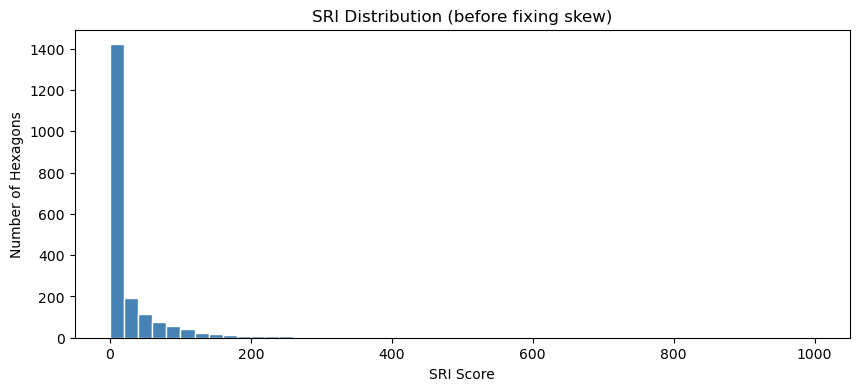

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.hist(sri_df['SRI'], bins=50, color='steelblue', edgecolor='white')
plt.xlabel('SRI Score')
plt.ylabel('Number of Hexagons')
plt.title('SRI Distribution (before fixing skew)')
plt.show()

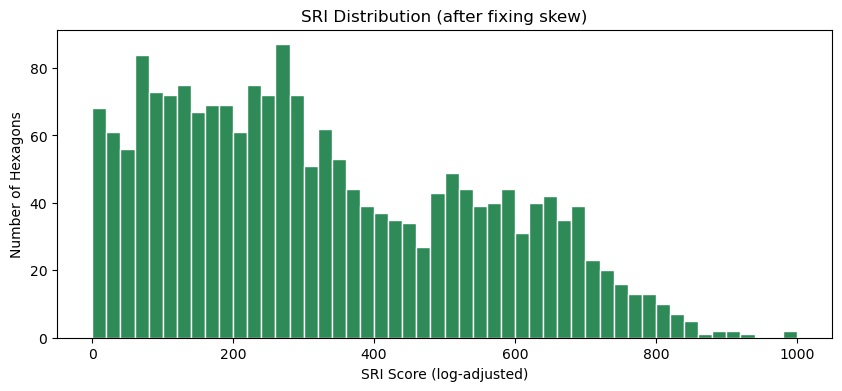

count    2004.000000
mean      327.868726
std       219.565043
min         0.000000
25%       144.720921
50%       283.787415
75%       507.124543
max      1000.000000
Name: SRI, dtype: float64


In [29]:
import numpy as np

# Log transformation lagate hain crime_rate pe (SRI banane se pehle)
# +1 isliye add karte hain kyunki log(0) undefined hota hai
sri_df['log_crime_rate'] = np.log1p(sri_df['crime_rate_per_1000'])

# Ab isi log-transformed value pe min-max scaling karo, 0-1000 range mein
min_log = sri_df['log_crime_rate'].min()
max_log = sri_df['log_crime_rate'].max()

sri_df['SRI'] = ((sri_df['log_crime_rate'] - min_log) / (max_log - min_log)) * 1000

plt.figure(figsize=(10, 4))
plt.hist(sri_df['SRI'], bins=50, color='seagreen', edgecolor='white')
plt.xlabel('SRI Score (log-adjusted)')
plt.ylabel('Number of Hexagons')
plt.title('SRI Distribution (after fixing skew)')
plt.show()

print(sri_df['SRI'].describe())

Text(0.5, 1.0, 'Bengaluru Safety Risk Index (SRI) — Final')

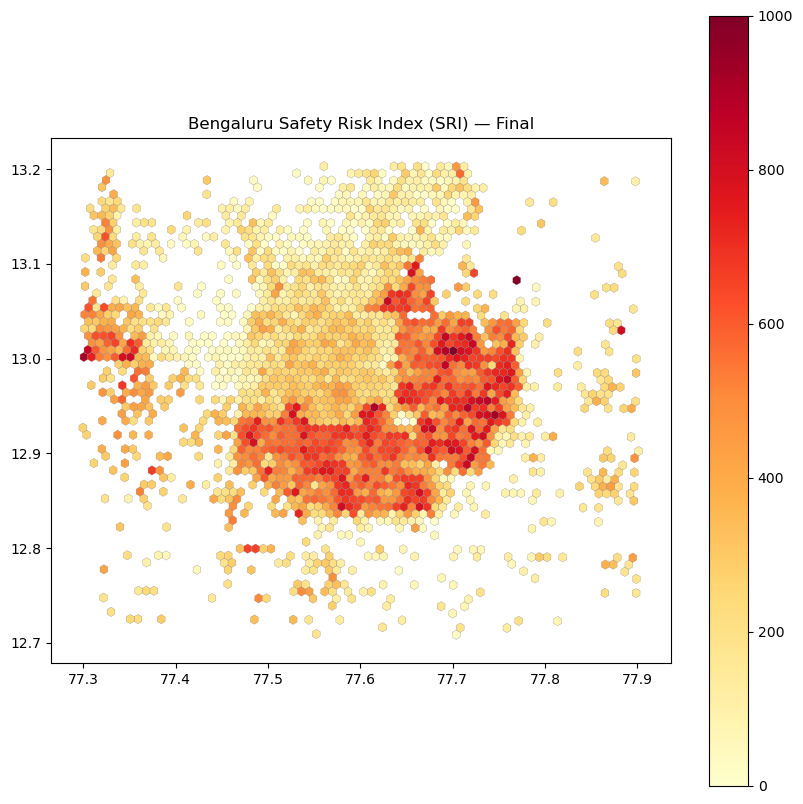

In [30]:
sri_df['geometry'] = sri_df['hex_id'].apply(hex_to_polygon)
sri_gdf = gpd.GeoDataFrame(sri_df, geometry='geometry', crs="EPSG:4326")

ax = sri_gdf.plot(
    column='SRI',
    cmap='YlOrRd',
    figsize=(10, 10),
    edgecolor='grey',
    linewidth=0.2,
    legend=True
)
ax.set_title("Bengaluru Safety Risk Index (SRI) — Final")

In [31]:
import osmnx as ox

print("osmnx load ho gaya, version:", ox.__version__)

osmnx load ho gaya, version: 2.1.1


In [32]:
# Bangalore ke andar saare "police station" tagged locations OSM se nikaalो
place_name = "Bengaluru, Karnataka, India"

police_tags = {"amenity": "police"}
police_stations = ox.features_from_place(place_name, police_tags)

print("Total police stations mile:", len(police_stations))
police_stations[['geometry']].head()

Total police stations mile: 138


geometry
element id                                  
node    295766640   POINT (77.55817 13.0182)
        303925790  POINT (77.58137 12.92857)
        428843493  POINT (77.59835 12.97624)
        428857750  POINT (77.56967 12.99668)
        521144416  POINT (77.54957 13.04865)

In [33]:
hospital_tags = {"amenity": "hospital"}
hospitals = ox.features_from_place(place_name, hospital_tags)

print("Total hospitals mile:", len(hospitals))
hospitals[['geometry']].head()

Total hospitals mile: 1072


geometry
element id                                  
node    267214379  POINT (77.67749 12.91342)
        303924572   POINT (77.58575 12.9235)
        307401529  POINT (77.67655 12.92637)
        308866071  POINT (77.63499 12.91558)
        310393723   POINT (77.64191 12.9129)

In [34]:
from scipy.spatial import cKDTree
import numpy as np

# Police stations aur hospitals ke center points nikaalो
police_stations['center'] = police_stations.geometry.centroid
hospitals['center'] = hospitals.geometry.centroid

police_coords = np.array([(pt.y, pt.x) for pt in police_stations['center']])  # (lat, lon)
hospital_coords = np.array([(pt.y, pt.x) for pt in hospitals['center']])

print("Police coords shape:", police_coords.shape)
print("Hospital coords shape:", hospital_coords.shape)

Police coords shape: (138, 2)
Hospital coords shape: (1072, 2)


/var/folders/rb/6sdjdvpn5plchw87422y61nh0000gn/T/ipykernel_52253/1858539391.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  police_stations['center'] = police_stations.geometry.centroid
/var/folders/rb/6sdjdvpn5plchw87422y61nh0000gn/T/ipykernel_52253/1858539391.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  hospitals['center'] = hospitals.geometry.centroid


In [35]:
# KDTree banao — ek fast "search structure" police aur hospital points ke liye
police_tree = cKDTree(police_coords)
hospital_tree = cKDTree(hospital_coords)

# Har hexagon ke center se nearest police station ki distance nikaalो
hex_coords = np.array(list(zip(sri_df['center_lat'], sri_df['center_lon'])))

police_dist, _ = police_tree.query(hex_coords)
hospital_dist, _ = hospital_tree.query(hex_coords)

sri_df['dist_to_police_deg'] = police_dist
sri_df['dist_to_hospital_deg'] = hospital_dist

print(sri_df[['hex_id', 'dist_to_police_deg', 'dist_to_hospital_deg']].head(10))

            hex_id  dist_to_police_deg  dist_to_hospital_deg
0  8860144003fffff            0.127041              0.118651
1  8860144005fffff            0.117003              0.104930
2  8860144007fffff            0.124969              0.113263
3  8860144009fffff            0.113170              0.108130
4  886014400dfffff            0.110820              0.102167
5  8860144011fffff            0.137924              0.132588
6  8860144017fffff            0.143393              0.135211
7  886014401dfffff            0.129654              0.124403
8  8860144021fffff            0.121973              0.103804
9  8860144023fffff            0.130165              0.112207


In [36]:
# Degrees ko approximately km mein convert karo
sri_df['dist_to_police_km'] = sri_df['dist_to_police_deg'] * 111
sri_df['dist_to_hospital_km'] = sri_df['dist_to_hospital_deg'] * 111

print(sri_df[['hex_id', 'dist_to_police_km', 'dist_to_hospital_km']].describe())

       dist_to_police_km  dist_to_hospital_km
count        2004.000000          2004.000000
mean            6.293035             5.034964
std             6.277379             5.932277
min             0.059774             0.006353
25%             1.450037             0.621497
50%             3.451236             2.070086
75%            10.082067             7.916666
max            26.609510            26.106340


In [37]:
# Purane SRI ko rename karo — crime-based hai
sri_df = sri_df.rename(columns={'SRI': 'crime_SRI'})

# Police aur hospital distance ko 0-1000 scale pe normalize karo (min-max)
# Jitna zyada distance, utna zyada risk — isliye seedha scale karenge (invert nahi karna)
for col, new_col in [('dist_to_police_km', 'police_access_SRI'), ('dist_to_hospital_km', 'hospital_access_SRI')]:
    min_val = sri_df[col].min()
    max_val = sri_df[col].max()
    sri_df[new_col] = ((sri_df[col] - min_val) / (max_val - min_val)) * 1000

# In dono ko average karke ek "access_SRI" banao
sri_df['access_SRI'] = (sri_df['police_access_SRI'] + sri_df['hospital_access_SRI']) / 2

print(sri_df[['hex_id', 'crime_SRI', 'access_SRI']].describe())

         crime_SRI   access_SRI
count  2004.000000  2004.000000
mean    327.868726   213.721991
std     219.565043   230.774711
min       0.000000     2.218704
25%     144.720921    39.319997
50%     283.787415   101.622033
75%     507.124543   341.192782
max    1000.000000  1000.000000


In [38]:
sri_df['final_SRI'] = (0.7 * sri_df['crime_SRI']) + (0.3 * sri_df['access_SRI'])

print(sri_df[['hex_id', 'crime_SRI', 'access_SRI', 'final_SRI']].sort_values('final_SRI', ascending=False).head(10))
print("\nFinal SRI stats:")
print(sri_df['final_SRI'].describe())

               hex_id    crime_SRI  access_SRI   final_SRI
233   8860144e61fffff   912.698734  778.909634  872.562004
234   8860144e65fffff   844.466336  764.924620  820.603821
1589  88618928c1fffff   992.872746  354.673565  801.412992
83    88601441e3fffff   830.453505  568.137844  751.758807
235   8860144e6dfffff   735.188768  743.986843  737.828190
57    8860144185fffff   791.259910  603.326383  734.879852
1994  8861893999fffff   810.611991  541.250807  729.803636
1793  8861892e29fffff  1000.000000   16.679652  705.003895
1101  886016b24bfffff   622.390539  824.694886  683.081843
239   8860144f07fffff   618.550544  789.617404  669.870602

Final SRI stats:
count    2004.000000
mean      293.624705
std       149.598754
min        17.117187
25%       170.332981
50%       280.466722
75%       413.615402
max       872.562004
Name: final_SRI, dtype: float64


In [39]:
sri_df.to_csv("data/hexagon_sri_data.csv", index=False)
print(sri_df.columns.tolist())
print(sri_df.shape)

['hex_id', 'raw_risk_score', 'population_density', 'center_lat', 'center_lon', 'crime_rate_per_1000', 'crime_SRI', 'log_crime_rate', 'geometry', 'dist_to_police_deg', 'dist_to_hospital_deg', 'dist_to_police_km', 'dist_to_hospital_km', 'police_access_SRI', 'hospital_access_SRI', 'access_SRI', 'final_SRI']
(2004, 17)


Text(0.5, 1.0, 'Bengaluru Final SRI (Crime + Emergency Access)')

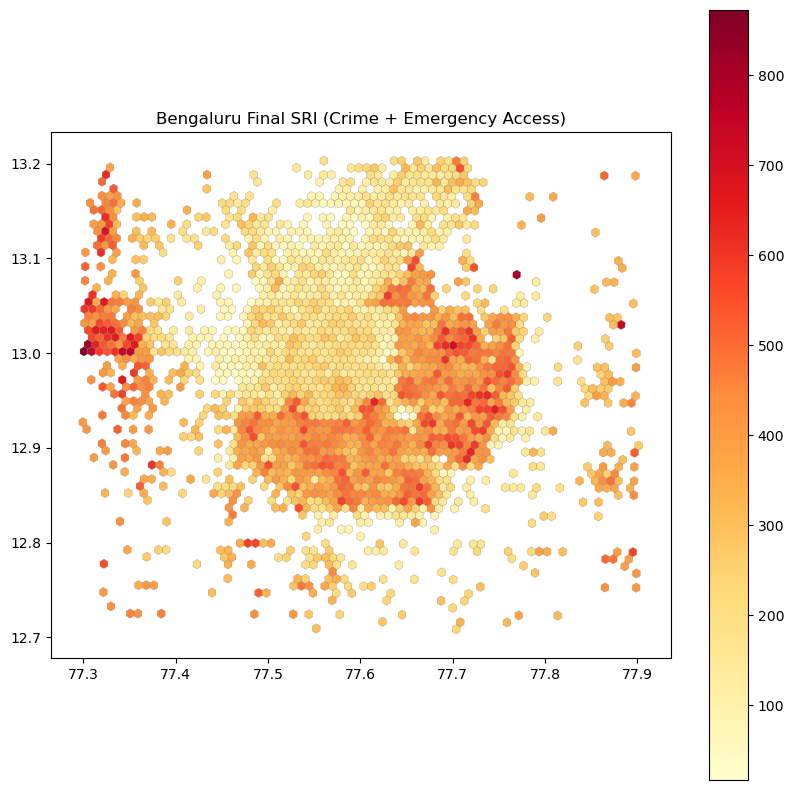

In [40]:
sri_df['geometry'] = sri_df['hex_id'].apply(hex_to_polygon)
final_gdf = gpd.GeoDataFrame(sri_df, geometry='geometry', crs="EPSG:4326")

ax = final_gdf.plot(
    column='final_SRI',
    cmap='YlOrRd',
    figsize=(10, 10),
    edgecolor='grey',
    linewidth=0.2,
    legend=True
)
ax.set_title("Bengaluru Final SRI (Crime + Emergency Access)")

In [41]:
# Pehle sirf header dekho, poori file load kiye bina
import pandas as pd
temp = pd.read_csv("data/FIR_Details_Data.csv", nrows=0)
print(list(temp.columns))

['District_Name', 'UnitName', 'FIR_YEAR', 'FIR_MONTH', 'Offence_Duration', 'FIR_Day', 'FIR Type', 'FIR_Stage', 'Complaint_Mode', 'CrimeGroup_Name', 'CrimeHead_Name', 'Latitude', 'Longitude', 'ActSection', 'IOName', 'KGID', 'Internal_IO', 'Place of Offence', 'Distance from PS', 'Beat_Name', 'Village_Area_Name', 'Male', 'Female', 'Boy', 'Girl', 'Age 0', 'VICTIM COUNT', 'Accused Count', 'Arrested Male', 'Arrested Female', 'Arrested Count\tNo.', 'Accused_ChargeSheeted Count', 'Conviction Count', 'Unit_ID']


In [42]:
crime_df = crime_df.rename(columns={'FIR Type': 'FIR_Type'})


In [43]:
crime_df = crime_df.rename(columns={'FIR Type': 'FIR_Type'})

In [44]:
cols_needed = ['District_Name', 'FIR_YEAR', 'FIR_MONTH', 'FIR Type', 
               'CrimeGroup_Name', 'Latitude', 'Longitude']
crime_df = pd.read_csv("data/FIR_Details_Data.csv", usecols=cols_needed)
print("Total records:", len(crime_df))

Total records: 1674734


In [45]:
crime_df = crime_df.rename(columns={'FIR Type': 'FIR_Type'})

In [46]:
check = pd.read_csv("data/hexagon_sri_data.csv")
print(check.shape)
print(check.columns.tolist())

(2004, 17)
['hex_id', 'raw_risk_score', 'population_density', 'center_lat', 'center_lon', 'crime_rate_per_1000', 'crime_SRI', 'log_crime_rate', 'geometry', 'dist_to_police_deg', 'dist_to_hospital_deg', 'dist_to_police_km', 'dist_to_hospital_km', 'police_access_SRI', 'hospital_access_SRI', 'access_SRI', 'final_SRI']


In [48]:
from sqlalchemy import create_engine
import geopandas as gpd

engine = create_engine('postgresql://rashisingh@localhost:5432/sentinel_db')

gdf = gpd.GeoDataFrame(sri_df, geometry='geometry', crs='EPSG:4326')

gdf_to_insert = gdf.rename(columns={
    'crime_SRI': 'crime_sri',
    'access_SRI': 'access_sri',
    'final_SRI': 'final_sri',
    'geometry': 'geom'
})[['hex_id', 'crime_rate_per_1000', 'population_density', 
    'dist_to_police_km', 'dist_to_hospital_km', 
    'crime_sri', 'access_sri', 'final_sri', 'geom']]

gdf_to_insert = gdf_to_insert.set_geometry('geom')

gdf_to_insert.to_postgis('hexagons', engine, if_exists='append', index=False)
print("Data inserted!", len(gdf_to_insert), "rows")

Data inserted! 2004 rows


In [50]:
police_df = police_stations[['geometry']].copy()
police_df['name'] = 'Police Station'
police_df['type'] = 'police'

hospital_df = hospitals[['geometry']].copy()
hospital_df['name'] = 'Hospital'
hospital_df['type'] = 'hospital'

facilities = pd.concat([police_df, hospital_df], ignore_index=True)
facilities['lat'] = facilities.geometry.centroid.y
facilities['lon'] = facilities.geometry.centroid.x

facilities[['name', 'type', 'lat', 'lon']].to_pickle("data/facilities.pkl")
print("Saved!", facilities.shape)

Saved! (1210, 5)


/var/folders/rb/6sdjdvpn5plchw87422y61nh0000gn/T/ipykernel_52253/2241678978.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  facilities['lat'] = facilities.geometry.centroid.y
/var/folders/rb/6sdjdvpn5plchw87422y61nh0000gn/T/ipykernel_52253/2241678978.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  facilities['lon'] = facilities.geometry.centroid.x


In [51]:
facilities[['name', 'type', 'lat', 'lon']].to_sql('facilities', engine, if_exists='append', index=False)
print("Facilities inserted!", len(facilities))

Facilities inserted! 1210
